# 4. Performance Tracking

## Overview
This notebook implements performance tracking for our ETF portfolio across all four asset classes, including:
1. Historical price data collection via yfinance
2. Return calculations (UK financial year Apr-Mar, YTD, MTD)
3. Risk metrics (volatility, Sharpe ratio)
4. Rebalancing-aware time-weighted return (TWR) from trading statements
5. Portfolio-level P&L and performance reporting

Portfolio data is loaded from the SQLite database (year = 2025), falling back to CSV.

## Required Libraries

In [7]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path("..").resolve()))

from datetime import datetime, timedelta

import pandas as pd
import numpy as np

from etf_utils.config import DATA_RAW, DATA_INTERMEDIATE, DATA_OUTPUT, DATA_CONFIG
from etf_utils.data_provider import DataProvider
from etf_utils.database import load_portfolio
from etf_utils.metrics import (
    calculate_annualized_volatility,
    calculate_period_metrics,
    calculate_daily_pnl,
)

provider = DataProvider()

# Load portfolio from DB (year=2025)
portfolio_df = load_portfolio(year=2025)
print(f"Loaded {len(portfolio_df)} positions from 2025 portfolio "
      f"(asset classes: {portfolio_df['asset_class'].unique().tolist()})")

Loaded 16 positions from 2025 portfolio (asset classes: ['equity', 'bonds'])


## 1. Rebalancing-Aware Portfolio Performance (Time-Weighted Return)

This section parses the InvestEngine trading statement to calculate a highly accurate
time-weighted return that explicitly accounts for actual rebalancing cash-flows over time.

### 1.1 Data Loading & Price Fetching

In [8]:
"""
Rebalancing-Aware Portfolio Performance — Data Loading
======================================================
Loads trades from CSV (or DB fallback) and fetches price data.
"""

import re
import importlib
from collections import defaultdict
import pandas as pd
import numpy as np
from pathlib import Path

# Reload data_provider to pick up the latest fixes
import etf_utils.data_provider
importlib.reload(etf_utils.data_provider)
from etf_utils.data_provider import DataProvider
from etf_utils.database import save_rebalancing_trades, load_rebalancing_trades
provider = DataProvider()

# ---------- 1. ISIN → Ticker mapping ----------
ISIN_TO_TICKER = {
    "IE00BZ163G84": "VECP",   # Vanguard EUR Corporate Bond
    "IE00B1XNH568": "IMIB",   # iShares FTSE MIB
    "IE00B0M63516": "IBZL",   # iShares MSCI Brazil
    "LU1048314949": "UC81",   # UBS US Liquid Corp Bonds
    "LU1931975152": "PRIR",   # Amundi Euro Govt Bonds
    "IE00B6TLBW47": "EMCP",   # iShares EM Corp Bond
    "IE00B00FV011": "SLXX",   # iShares Corporate Bond
    "IE00BD4TY345": "AUAD",   # UBS MSCI Australia
    "IE00B1FZSB30": "IGLT",   # iShares Core UK Gilts
    "IE00BF2FN646": "TRXG",   # Invesco US Treasury 7-10Y
    "IE00B44T3H88": "HMCH",   # HSBC MSCI China
    "LU0838782315": "XDDX",   # Xtrackers DAX
    "IE00BZ163L38": "VEMT",   # Vanguard EM Govt Bonds
    "LU1931974775": "PRIJ",   # Amundi Prime Japan
    "IE00BM8R0J59": "QYLP",   # Global X Nasdaq 100 CC
    "LU1781541096": "LCUK",   # Amundi Core UK Equity
}

from etf_utils.config import PROJECT_ROOT

# ---------- 2. Load trades: CSV (parse + save to DB) or DB fallback ----------
PORTFOLIO_YEAR = 2025

statement_path = (
    PROJECT_ROOT
    / "data"
    / "investment_statements"
    / f"RebalancingTrades{PORTFOLIO_YEAR}.csv"
)

if statement_path.exists():
    trades_raw = pd.read_csv(statement_path, skiprows=2, header=None,
                             names=["security", "type", "quantity", "price", "value",
                                    "trade_datetime", "settlement_date", "broker"])

    trades_raw["isin"] = trades_raw["security"].str.extract(r"ISIN\s+([A-Z]{2}[A-Z0-9]{10})")
    trades_raw["ticker"] = trades_raw["isin"].map(ISIN_TO_TICKER)

    trades_raw["trade_date"] = pd.to_datetime(
        trades_raw["trade_datetime"].str.strip(), format="%d/%m/%y %H:%M:%S"
    ).dt.normalize()

    trades_raw["quantity"] = pd.to_numeric(trades_raw["quantity"], errors="coerce")
    trades_raw["price"] = (
        trades_raw["price"].astype(str).str.replace("\u00a3", "", regex=False).str.replace(",", "")
    )
    trades_raw["price"] = pd.to_numeric(trades_raw["price"], errors="coerce")
    trades_raw["value"] = (
        trades_raw["value"].astype(str).str.replace("\u00a3", "", regex=False).str.replace(",", "")
    )
    trades_raw["value"] = pd.to_numeric(trades_raw["value"], errors="coerce")

    trades = trades_raw.dropna(subset=["ticker", "trade_date"]).copy()

    trades["signed_qty"] = trades.apply(
        lambda r: r["quantity"] if r["type"].strip() == "Buy" else -r["quantity"], axis=1
    )
    trades["signed_value"] = trades.apply(
        lambda r: r["value"] if r["type"].strip() == "Buy" else -r["value"], axis=1
    )

    save_rebalancing_trades(trades, portfolio_year=PORTFOLIO_YEAR)
    print(f"Parsed CSV and saved {len(trades)} trades to DB for year {PORTFOLIO_YEAR}")
else:
    trades = load_rebalancing_trades(portfolio_year=PORTFOLIO_YEAR)
    if trades.empty:
        raise FileNotFoundError(
            f"No trading statement CSV at {statement_path} and no trades in DB "
            f"for portfolio year {PORTFOLIO_YEAR}"
        )
    trades["trade_date"] = pd.to_datetime(trades["trade_date"])
    print(f"Loaded {len(trades)} trades from DB for year {PORTFOLIO_YEAR}")

print(f"Loaded {len(trades)} transactions for {trades['ticker'].nunique()} tickers")
print(f"Date range: {trades['trade_date'].min().date()} to {trades['trade_date'].max().date()}")

rebalance_dates = sorted(trades["trade_date"].unique())

# ---------- 3. Fetch price data ----------
all_tickers = sorted(trades["ticker"].unique().tolist())
price_data = {}
for ticker in all_tickers:
    try:
        price_data[ticker] = provider.get_historical_prices(ticker)
    except Exception as e:
        print(f"  Warning: could not fetch data for {ticker}: {e}")

def get_price_at(ticker, date):
    if ticker not in price_data: return None
    df = price_data[ticker]
    match = df[df.index <= date]
    return float(match["close"].iloc[-1]) if not match.empty else None

# Compute share ledger and cost basis from all trades
first_trade_date = trades["trade_date"].min()
today = pd.Timestamp.now().normalize()

share_ledger = defaultdict(float)
cost_basis = defaultdict(float)
for _, t in trades.iterrows():
    share_ledger[t["ticker"]] += t["signed_qty"]
    cost_basis[t["ticker"]] += t["signed_value"]

print(f"\nComputed share ledger for {len(share_ledger)} tickers")
print(f"Period: {first_trade_date.date()} → {today.date()}")

Parsed CSV and saved 351 trades to DB for year 2025
Loaded 351 transactions for 16 tickers
Date range: 2025-05-12 to 2026-03-23

Computed share ledger for 16 tickers
Period: 2025-05-12 → 2026-04-06


### 1.2 Individual Ticker Performance

Compares each ETF's pure price return over the period against the personal
money-weighted return (MWR) based on actual shares bought/sold.

In [9]:
# Calculate weight based on first day deposits
first_day_trades = trades[trades["trade_date"] == first_trade_date]
initial_deposits = {}
for _, t in first_day_trades.iterrows():
    initial_deposits[t["ticker"]] = initial_deposits.get(t["ticker"], 0) + t["signed_value"]
total_initial_cash = sum(v for v in initial_deposits.values() if v > 0)

ticker_rows = []
for ticker in all_tickers:
    if ticker not in price_data:
        continue
    df = price_data[ticker]

    # Prices for pure period return
    after_start = df[df.index >= first_trade_date]
    before_end = df[df.index <= today]
    if after_start.empty or before_end.empty:
        continue

    px_start = float(after_start["close"].iloc[0])
    px_end = float(before_end["close"].iloc[-1])
    price_ret = ((px_end / px_start) - 1) * 100

    # Personal money-weighted return for this ticker
    net_cost = cost_basis.get(ticker, 0)
    shares = share_ledger.get(ticker, 0)
    current_val = shares * px_end if shares > 0 else 0
    my_ret = ((current_val - net_cost) / net_cost * 100) if net_cost > 0 else 0

    # First trade price for reference
    first_px = trades[trades["ticker"] == ticker].iloc[0]["price"]

    weight = (initial_deposits.get(ticker, 0) / total_initial_cash * 100) if total_initial_cash > 0 else 0

    ticker_rows.append({
        "Ticker": ticker,
        "Start Date": after_start.index[0].date(),
        "End Date": before_end.index[-1].date(),
        "Trade Price (£)": round(first_px, 2),
        "DP Start": round(px_start, 2),
        "DP End": round(px_end, 2),
        "Price Return (%)": round(price_ret, 2),
        "My Return (%)": round(my_ret, 2),
        "Weight (%)": round(weight, 1),
    })

ticker_perf_df = pd.DataFrame(ticker_rows)
display(ticker_perf_df)

,Ticker,Start Date,End Date,Trade Price (£),DP Start,DP End,Price Return (%),My Return (%),Weight (%)
0,AUAD,2025-05-12,2026-04-02,18.39,17.79,20.62,15.91,12.40,16.0
1,EMCP,2025-05-12,2026-04-02,68.33,63.67,67.32,5.73,-1.07,1.0
2,HMCH,2025-05-12,2026-04-02,5.69,5.56,5.79,4.07,1.47,2.0
3,IBZL,2025-05-12,2026-04-02,16.84,15.72,23.48,49.42,48.14,8.0
4,IGLT,2025-05-12,2026-04-02,9.98,9.56,9.82,2.72,-1.54,1.0
5,IMIB,2025-05-12,2026-04-02,20.43,19.61,24.14,23.13,18.25,18.0
6,LCUK,2025-05-12,2026-04-02,12.16,12.19,14.55,19.41,19.82,9.0
7,PRIJ,2025-05-12,2026-04-02,24.12,24.18,29.02,20.05,21.68,7.0
8,PRIR,2025-05-12,2026-04-02,14.52,14.50,14.70,1.39,0.98,3.0
9,QYLP,2025-05-12,2026-04-02,11.94,10.90,12.29,12.68,2.95,7.0


### 1.3 Portfolio Performance Summary

Time-Weighted Return (TWR) chains sub-period returns across rebalancing events to
measure strategy performance independent of cash-flow timing. Money-Weighted Return
(MWR) reflects personal investor experience including contribution timing.

In [10]:
# ---------- Calculate Time-Weighted Return (TWR) ----------
remaining_rebalance_dates = [d for d in rebalance_dates if d > first_trade_date]
period_boundaries = sorted(set([first_trade_date] + remaining_rebalance_dates + [today]))

running_shares = defaultdict(float)
sub_period_returns = []

for i in range(len(period_boundaries) - 1):
    p_start, p_end = period_boundaries[i], period_boundaries[i+1]

    # 1. Update holdings with trades happening EXACTLY at p_start
    start_trades = trades[trades["trade_date"] == p_start]
    for _, t in start_trades.iterrows():
        running_shares[t["ticker"]] += t["signed_qty"]

    # 2. Calculate portfolio value at start of period (post-trade)
    val_start = 0
    for tkr, qty in running_shares.items():
        price = get_price_at(tkr, p_start)
        if price: val_start += qty * price

    if val_start <= 0: continue

    # 3. Calculate portfolio value at end of period (pre-trade/p_end)
    val_end_pre = 0
    for tkr, qty in running_shares.items():
        price = get_price_at(tkr, p_end)
        if price: val_end_pre += qty * price

    # 4. Period return (Asset performance during this time slice)
    sp_ret = (val_end_pre / val_start) - 1

    sub_period_returns.append({
        "period_start": p_start,
        "period_end": p_end,
        "days": (p_end - p_start).days,
        "portfolio_value_start": round(val_start, 2),
        "portfolio_value_end": round(val_end_pre, 2),
        "sub_period_return": sp_ret
    })

# Chain TWR
cumulative_twr = 1.0
for sp in sub_period_returns:
    cumulative_twr *= (1 + sp["sub_period_return"])
    sp["cumulative_return"] = (cumulative_twr - 1) * 100

total_twr = (cumulative_twr - 1) * 100

# Money-Weighted Return (MWR)
# Actual cash deposited (excludes dividend reinvestment which appears as trades)
CASH_DEPOSITED = 20_000
total_trade_cost = sum(cost_basis.values())
estimated_dividends_reinvested = total_trade_cost - CASH_DEPOSITED
total_net_input = CASH_DEPOSITED
total_current_value = 0
for t, shares in share_ledger.items():
    px = get_price_at(t, today)
    if px: total_current_value += shares * px
mwr_return = (total_current_value / total_net_input - 1) * 100

# Portfolio summary table
summary_data = {
    "Metric": [
        "Time-Weighted Return (TWR)",
        "Money-Weighted Return (MWR)",
        "Net Cash Contributions",
        "Current Portfolio Value",
        "Absolute P&L",
    ],
    "Value": [
        f"{total_twr:.2f}%",
        f"{mwr_return:.2f}%",
        f"£{total_net_input:,.2f}",
        f"£{total_current_value:,.2f}",
        f"£{total_current_value - total_net_input:,.2f}",
    ],
}
summary_df = pd.DataFrame(summary_data)
display(summary_df)

# Sub-period detail table
print("\nSub-Period Detail (TWR Segments):")
sp_df = pd.DataFrame(sub_period_returns)
sp_df["sub_period_return"] = (sp_df["sub_period_return"] * 100).round(2)
sp_df["cumulative_return"] = sp_df["cumulative_return"].round(2)
sp_df["period_start"] = sp_df["period_start"].dt.date
sp_df["period_end"] = sp_df["period_end"].dt.date
sp_df.columns = ["Period Start", "Period End", "Days", "Value Start (£)", "Value End (£)", "Period Return (%)", "Cumulative Return (%)"]
display(sp_df)

,Metric,Value
0,Time-Weighted Return (TWR),15.43%
1,Money-Weighted Return (MWR),15.55%
2,Net Cash Contributions,"£20,000.00"
3,Current Portfolio Value,"£23,110.62"
4,Absolute P&L,"£3,110.62"



Sub-Period Detail (TWR Segments):


,Period Start,Period End,Days,Value Start (£),Value End (£),Period Return (%),Cumulative Return (%)
0,2025-05-12,2025-06-23,42,19318.81,19415.71,0.50,0.50
1,2025-06-23,2025-07-03,10,19516.43,19960.81,2.28,2.79
2,2025-07-03,2025-07-21,18,19993.12,20136.03,0.71,3.52
3,2025-07-21,2025-07-30,9,20152.83,20405.97,1.26,4.83
4,2025-07-30,2025-08-11,12,20404.96,20550.84,0.71,5.57
5,2025-08-11,2025-08-26,15,20606.57,20799.34,0.94,6.56
6,2025-08-26,2025-09-15,20,20813.32,20952.51,0.67,7.27
7,2025-09-15,2025-09-30,15,21057.97,21176.56,0.56,7.88
8,2025-09-30,2025-10-13,13,21210.41,21166.90,-0.21,7.66
9,2025-10-13,2025-10-20,7,21167.93,21396.78,1.08,8.82


### 1.3.1 Rebalancing Impact Analysis (Buy & Hold Counterfactual)

Calculates what the initial Day 1 investment would be worth today if no further trading 
or rebalancing was ever performed. Comparing this to the actual TWR reveals whether the 
automated rebalancing sequence added or destroyed value.

In [11]:
# ---------- Theoretical "Buy and Hold" Counterfactual ----------
# What if we had taken the initial investment on May 12th, bought the starting
# allocation, and NEVER rebalanced?
#
# Uses adjusted close price ratios so dividends are automatically captured
# (data provider returns dividend-adjusted prices).

bnh_cost = 0
bnh_ticker_cost = {}
bnh_holdings = {}

for _, t in first_day_trades.iterrows():
    bnh_cost += t["signed_value"]
    bnh_ticker_cost[t["ticker"]] = bnh_ticker_cost.get(t["ticker"], 0) + t["signed_value"]
    bnh_holdings[t["ticker"]] = bnh_holdings.get(t["ticker"], 0) + t["signed_qty"]

# Calculate B&H return using adjusted price ratios (includes implied dividend reinvestment)
bnh_weighted_return = 0
bnh_price_only_return = 0
bnh_rows = []
for ticker, cost in bnh_ticker_cost.items():
    if cost <= 0: continue
    shares = bnh_holdings[ticker]
    adj_px_start = get_price_at(ticker, first_trade_date)
    adj_px_end = get_price_at(ticker, today)
    if adj_px_start and adj_px_end:
        # Total return (price + implied dividends reinvested) via adjusted prices
        ticker_total_return = (adj_px_end / adj_px_start) - 1
        # Price-only return (shares x current price vs cost)
        ticker_price_return = ((shares * adj_px_end) / cost) - 1
        weight = cost / bnh_cost
        bnh_weighted_return += ticker_total_return * weight
        bnh_price_only_return += ticker_price_return * weight
        bnh_rows.append({
            "Ticker": ticker,
            "Weight (%)": round(weight * 100, 1),
            "Adj Start": round(adj_px_start, 2),
            "Adj End": round(adj_px_end, 2),
            "Price Return (%)": round(ticker_price_return * 100, 2),
            "Total Return (%)": round(ticker_total_return * 100, 2),
        })

bnh_total_return = bnh_weighted_return * 100
bnh_price_return = bnh_price_only_return * 100
bnh_implied_dividends = bnh_total_return - bnh_price_return
bnh_estimated_value = bnh_cost * (1 + bnh_weighted_return)

print("=" * 65)
print("REBALANCING IMPACT ANALYSIS: Buy & Hold Counterfactual")
print("=" * 65)
print(f"Initial Investment (Day 1):       \u00a3{bnh_cost:,.2f}")
print(f"B&H Price-Only Return:            {bnh_price_return:.2f}%")
print(f"B&H Implied Dividends Reinvested: +{bnh_implied_dividends:.2f}%")
print(f"B&H Total Return (inc. divs):     {bnh_total_return:.2f}%")
print(f"B&H Est. Value (inc. divs):       \u00a3{bnh_estimated_value:,.2f}")
print(f"")
print(f"Actual Portfolio Return (TWR):    {total_twr:.2f}%")
diff = total_twr - bnh_total_return
impact = "HELPED" if diff > 0 else "HURT (Drag)"
print(f"Net Rebalancing Impact:           {diff:+.2f}%  ({impact})")

print("\nPer-Ticker Buy & Hold Breakdown:")
display(pd.DataFrame(bnh_rows).sort_values("Total Return (%)", ascending=False))


REBALANCING IMPACT ANALYSIS: Buy & Hold Counterfactual
Initial Investment (Day 1):       £19,988.32
B&H Price-Only Return:            11.76%
B&H Implied Dividends Reinvested: +3.97%
B&H Total Return (inc. divs):     15.73%
B&H Est. Value (inc. divs):       £23,132.16

Actual Portfolio Return (TWR):    15.43%
Net Rebalancing Impact:           -0.30%  (HURT (Drag))

Per-Ticker Buy & Hold Breakdown:


,Ticker,Weight (%),Adj Start,Adj End,Price Return (%),Total Return (%)
2,IBZL,8.0,15.72,23.48,39.42,49.42
1,IMIB,18.0,19.61,24.14,18.19,23.13
13,PRIJ,7.0,24.18,29.02,20.33,20.05
15,LCUK,9.0,12.19,14.55,19.64,19.41
7,AUAD,16.0,17.79,20.62,12.14,15.91
14,QYLP,7.0,10.90,12.29,2.91,12.68
12,VEMT,1.0,30.34,32.71,1.93,7.83
5,EMCP,1.0,63.67,67.32,-1.47,5.73
0,VECP,6.0,39.68,41.81,1.93,5.36
9,TRXG,1.0,25.64,26.93,0.70,5.05


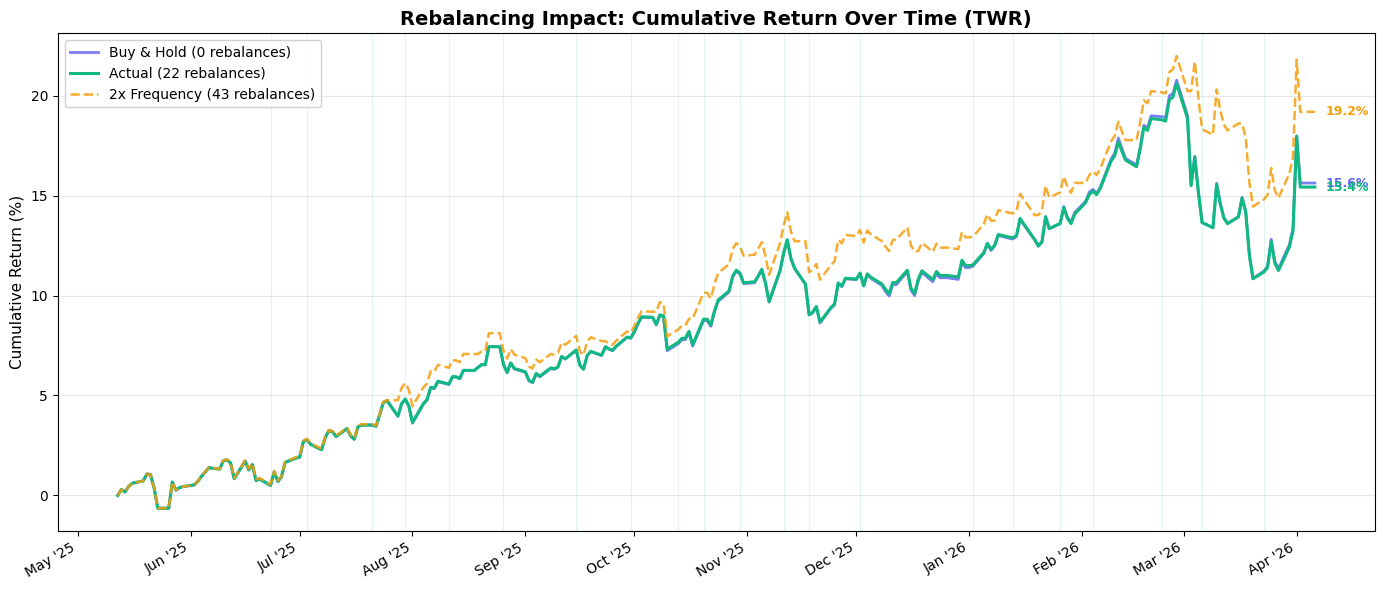


Final Cumulative Returns (TWR):
  Buy & Hold:              15.63%
  Actual (22 rebalances):  15.43%
  2x Frequency (43 rebal):  19.20%


In [12]:
# ---------- Rebalancing Impact Chart: B&H vs Actual vs 2x Rebalances ----------
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Common setup ---
all_dates = pd.bdate_range(first_trade_date, today)

# Target weights from initial allocation
target_weights = {}
for tkr, cost in bnh_ticker_cost.items():
    target_weights[tkr] = cost / bnh_cost

def portfolio_value_on(shares_dict, date):
    val = 0
    for tkr, qty in shares_dict.items():
        px = get_price_at(tkr, date)
        if px: val += qty * px
    return val

def rebalance_to_targets(total_value, target_wts, date):
    new_shares = {}
    for tkr, wt in target_wts.items():
        px = get_price_at(tkr, date)
        if px and px > 0:
            new_shares[tkr] = (total_value * wt) / px
        else:
            new_shares[tkr] = 0
    return new_shares

def compute_daily_twr(all_dates, rebal_dates, get_shares_after_rebal):
    """Compute daily cumulative TWR for any rebalancing strategy.
    
    get_shares_after_rebal(date, current_shares, portfolio_value) -> new_shares
    """
    sorted_rebals = sorted(rebal_dates)
    
    # Build list of sub-periods: [(start_date, end_date, shares_held), ...]
    sub_periods = []
    current_shares = get_shares_after_rebal(sorted_rebals[0], {}, 0)
    
    for i in range(len(sorted_rebals)):
        p_start = sorted_rebals[i]
        p_end = sorted_rebals[i + 1] if i + 1 < len(sorted_rebals) else all_dates[-1] + pd.Timedelta(days=1)
        sub_periods.append((p_start, p_end, dict(current_shares)))
        
        # Rebalance at next date
        if i + 1 < len(sorted_rebals):
            val = portfolio_value_on(current_shares, sorted_rebals[i + 1])
            current_shares = get_shares_after_rebal(sorted_rebals[i + 1], current_shares, val)
    
    # Compute daily cumulative TWR
    cumulative_factor = 1.0
    daily_returns = []
    sp_idx = 0
    sub_start_val = None
    
    for d in all_dates:
        # Move to next sub-period if needed
        while sp_idx < len(sub_periods) - 1 and d >= sub_periods[sp_idx + 1][0]:
            # Close out current sub-period
            if sub_start_val and sub_start_val > 0:
                sub_end_val = portfolio_value_on(sub_periods[sp_idx][2], sub_periods[sp_idx + 1][0])
                cumulative_factor *= (sub_end_val / sub_start_val)
            sp_idx += 1
            sub_start_val = None
        
        shares = sub_periods[sp_idx][2]
        day_val = portfolio_value_on(shares, d)
        
        if sub_start_val is None:
            sub_start_val = day_val
        
        if sub_start_val and sub_start_val > 0:
            intra_growth = day_val / sub_start_val
            daily_returns.append((cumulative_factor * intra_growth - 1) * 100)
        else:
            daily_returns.append(0)
    
    return daily_returns

# --- Strategy 1: Buy & Hold (no rebalancing - simple ratio) ---
bnh_shares_fixed = dict(bnh_holdings)
bnh_base = portfolio_value_on(bnh_shares_fixed, all_dates[0])
bnh_returns = []
for d in all_dates:
    val = portfolio_value_on(bnh_shares_fixed, d)
    bnh_returns.append((val / bnh_base - 1) * 100 if bnh_base > 0 else 0)

# --- Strategy 2: Actual portfolio (daily TWR chained at rebalance boundaries) ---
sorted_rebal = sorted(rebalance_dates)

def actual_shares_after_rebal(date, current_shares, portfolio_value):
    new_shares = dict(current_shares)
    day_trades = trades[trades["trade_date"] == date]
    for _, t in day_trades.iterrows():
        new_shares[t["ticker"]] = new_shares.get(t["ticker"], 0) + t["signed_qty"]
    return new_shares

actual_returns = compute_daily_twr(all_dates, sorted_rebal, actual_shares_after_rebal)

# --- Strategy 3: 2x Frequency (insert midpoint rebalances to target weights) ---
double_rebal_dates = []
for i in range(len(sorted_rebal)):
    double_rebal_dates.append(sorted_rebal[i])
    if i < len(sorted_rebal) - 1:
        mid = sorted_rebal[i] + (sorted_rebal[i+1] - sorted_rebal[i]) / 2
        mid_bday = mid + pd.tseries.offsets.BDay(0)
        double_rebal_dates.append(mid_bday)
double_rebal_dates = sorted(set(double_rebal_dates))

actual_rebal_set = set(sorted_rebal)

def double_shares_after_rebal(date, current_shares, portfolio_value):
    if date in actual_rebal_set:
        # On actual rebalance dates, apply actual trades
        new_shares = dict(current_shares)
        day_trades = trades[trades["trade_date"] == date]
        for _, t in day_trades.iterrows():
            new_shares[t["ticker"]] = new_shares.get(t["ticker"], 0) + t["signed_qty"]
        return new_shares
    else:
        # On inserted midpoint dates, rebalance to target weights
        if portfolio_value > 0:
            return rebalance_to_targets(portfolio_value, target_weights, date)
        return current_shares

double_returns = compute_daily_twr(all_dates, double_rebal_dates, double_shares_after_rebal)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(all_dates, bnh_returns, label="Buy & Hold (0 rebalances)", 
        color="#6366f1", linewidth=2, alpha=0.85)
ax.plot(all_dates, actual_returns, label=f"Actual ({len(sorted_rebal)} rebalances)", 
        color="#10b981", linewidth=2.2)
ax.plot(all_dates, double_returns, label=f"2x Frequency ({len(double_rebal_dates)} rebalances)", 
        color="#f59e0b", linewidth=1.8, linestyle="--", alpha=0.85)

# Mark actual rebalance dates
for rd in sorted_rebal[1:]:
    ax.axvline(rd, color="#10b981", alpha=0.12, linewidth=0.8)

ax.set_title("Rebalancing Impact: Cumulative Return Over Time (TWR)", fontsize=14, fontweight="bold")
ax.set_ylabel("Cumulative Return (%)", fontsize=11)
ax.set_xlabel("")
ax.legend(loc="upper left", fontsize=10, framealpha=0.9)
ax.grid(axis="y", alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate(rotation=30)

# Annotate final values
for label, vals, color in [
    ("B&H", bnh_returns, "#6366f1"),
    ("Actual", actual_returns, "#10b981"),
    ("2x", double_returns, "#f59e0b"),
]:
    final = vals[-1]
    ax.annotate(f"{final:.1f}%", xy=(all_dates[-1], final),
                xytext=(8, 0), textcoords="offset points",
                fontsize=9, fontweight="bold", color=color, va="center")

plt.tight_layout()
plt.show()

print(f"\nFinal Cumulative Returns (TWR):")
print(f"  Buy & Hold:              {bnh_returns[-1]:.2f}%")
print(f"  Actual ({len(sorted_rebal)} rebalances):  {actual_returns[-1]:.2f}%")
print(f"  2x Frequency ({len(double_rebal_dates)} rebal):  {double_returns[-1]:.2f}%")


### 1.4 Current Holdings (Share-Based)

Live snapshot of all held positions with current market value, cost basis,
and per-ticker money-weighted return.

In [ ]:
holdings_rows = []
for t in sorted(share_ledger.keys()):
    shares = share_ledger[t]
    if shares <= 0: continue
    px = get_price_at(t, today) or 0
    val = round(shares * px, 2)
    cost = cost_basis[t]
    ticker_mwr = ((val / cost) - 1) * 100 if cost > 0 else 0
    holdings_rows.append({
        "Ticker": t,
        "Shares": round(shares, 4),
        "Price (£)": round(px, 2),
        "Value (£)": val,
        "Cost (£)": round(cost, 2),
        "P&L (£)": round(val - cost, 2),
        "MWR (%)": round(ticker_mwr, 2),
    })

holdings_df = pd.DataFrame(holdings_rows)
display(holdings_df)
print(f"Total Portfolio Value: £{holdings_df['Value (£)'].sum():,.2f}")
print(f"Total Cost Basis:     £{holdings_df['Cost (£)'].sum():,.2f}")
print(f"Total P&L:            £{holdings_df['P&L (£)'].sum():,.2f}")

## 2. Recent Performance Metrics (YTD and MTD)

Calculate basic Year-to-Date (2025) and Month-to-Date momentum indicators.

In [ ]:
# Calculate YTD and MTD performance using DataProvider
ytd_start = "2025-01-01"
mtd_start = "2025-02-01"

ytd_performance = []
mtd_performance = []

for idx, row in portfolio_df.iterrows():
    try:
        df = provider.get_historical_prices(row['ticker'])
        weight = row['investment'] / portfolio_df['investment'].sum()

        # YTD metrics
        ytd = calculate_period_metrics(df, ytd_start)
        if ytd and not np.isnan(ytd['return']):
            ytd_performance.append({
                'ETF': row['ticker'],
                'Return (%)': round(ytd['return'] * 100, 2),
                'Volatility (%)': round(ytd['volatility'] * 100, 2),
                'Weight': weight,
                'Weighted Return (%)': round(ytd['return'] * 100 * weight, 2),
                'Weighted Volatility (%)': round(ytd['volatility'] * 100 * weight, 2),
            })

        # MTD metrics
        mtd = calculate_period_metrics(df, mtd_start)
        if mtd and not np.isnan(mtd['return']):
            mtd_performance.append({
                'ETF': row['ticker'],
                'Return (%)': round(mtd['return'] * 100, 2),
                'Volatility (%)': round(mtd['volatility'] * 100, 2),
                'Weight': weight,
                'Weighted Return (%)': round(mtd['return'] * 100 * weight, 2),
                'Weighted Volatility (%)': round(mtd['volatility'] * 100 * weight, 2),
            })
    except Exception as e:
        print(f"Error processing {row['ticker']}: {str(e)}")

ytd_df = pd.DataFrame(ytd_performance)
mtd_df = pd.DataFrame(mtd_performance)

if not ytd_df.empty:
    print("\nYear to Date (2025) Portfolio Performance:")
    print(f"Total Return: {ytd_df['Weighted Return (%)'].sum():.2f}%")
    print(f"Portfolio Volatility: {ytd_df['Weighted Volatility (%)'].sum():.2f}%")
    print("\nTop 3 YTD Contributors:")
    display(ytd_df.nlargest(3, 'Weighted Return (%)')[['ETF', 'Return (%)', 'Weighted Return (%)']])

if not mtd_df.empty:
    print("\nMonth to Date Portfolio Performance:")
    print(f"Total Return: {mtd_df['Weighted Return (%)'].sum():.2f}%")
    print(f"Portfolio Volatility: {mtd_df['Weighted Volatility (%)'].sum():.2f}%")

# YTD Sharpe ratio
risk_free_rate = 0.04
if not ytd_df.empty:
    ytd_return = ytd_df['Weighted Return (%)'].sum() / 100
    ytd_vol = ytd_df['Weighted Volatility (%)'].sum() / 100
    ytd_sharpe = (ytd_return - risk_free_rate * 0.5) / ytd_vol if ytd_vol > 0 else float('nan')
    print(f"\nYTD Sharpe Ratio: {ytd_sharpe:.2f}")

## 3. Daily PnL Tracking & Plotting

Visual tracking of raw PnL values and timeline graphs for designated assets.

In [ ]:
# Calculate daily PnL for the portfolio using DataProvider
pnl_start = "2025-02-01"

daily_pnl_list = []

for idx, row in portfolio_df.iterrows():
    try:
        df = provider.get_historical_prices(row['ticker'])
        pnl_df = calculate_daily_pnl(df, row['investment'], pnl_start)

        if pnl_df is not None and not pnl_df.empty:
            weight = row['investment'] / portfolio_df['investment'].sum()
            pnl_df = pnl_df.copy()
            pnl_df['ETF'] = row['ticker']
            pnl_df['Weight'] = weight
            pnl_df['Weighted PnL'] = pnl_df['pnl'] * weight
            daily_pnl_list.append(pnl_df)
    except Exception as e:
        print(f"Error processing {row['ticker']}: {str(e)}")

if daily_pnl_list:
    daily_pnl = pd.concat(daily_pnl_list)
    print("\nDaily PnL Summary by ETF:")
    display(daily_pnl.groupby('ETF')['Weighted PnL'].sum().sort_values(ascending=False))

    # Portfolio-level daily PnL
    portfolio_daily = daily_pnl.groupby(daily_pnl.index)['Weighted PnL'].sum()
    print(f"\nTotal Portfolio PnL since {pnl_start}: {portfolio_daily.sum():.2f}")
else:
    print("No PnL data available")

In [ ]:
import plotly.graph_objects as go

# Plot daily returns for a selected ETF
selected_etf = "AUAD"
etf_data = daily_pnl[daily_pnl['ETF'] == selected_etf].copy()

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=etf_data.index,
        y=etf_data['daily_return'],
        mode='lines+markers',
        name='Daily Return',
        line=dict(color='blue'),
        hovertemplate='Date: %{x}<br>Return: %{y:.2%}<extra></extra>'
    )
)

fig.update_layout(
    title=f'{selected_etf} ETF Daily Returns',
    xaxis_title='Date',
    yaxis_title='Daily Return',
    yaxis_tickformat='.2%',
    hovermode='x unified',
    template='plotly_white',
    width=1000,
    height=600
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
fig.show()

In [ ]:
# Show recent data for selected ETF
etf_data.tail(10)

In [ ]:
# Portfolio-level daily PnL
portfolio_daily_pnl = daily_pnl.groupby(daily_pnl.index)['Weighted PnL'].sum()
portfolio_daily_pnl.tail(10)

## 5. Legacy/Static Metrics (Less Useful)

These cells perform point-in-time percentage checks using `calculate_etf_metrics` without respecting true rebalancing quantities. They are kept here strictly for reference.

In [ ]:
def calculate_etf_metrics(symbol, fy_start_years=range(2020, 2026)):
    """Calculate UK financial year (Apr-Mar) performance metrics for an ETF using DataProvider."""
    df = provider.get_historical_prices(symbol)
    annual_results = []

    for start_year in fy_start_years:
        fy_start = pd.Timestamp(f"{start_year}-04-01")
        fy_end = pd.Timestamp(f"{start_year + 1}-03-31")

        df_fy = df[(df.index >= fy_start) & (df.index <= fy_end)]
        if len(df_fy) < 2:
            continue

        start_price = df_fy["close"].iloc[0]
        end_price = df_fy["close"].iloc[-1]
        annual_return = ((end_price / start_price) - 1) * 100
        volatility = calculate_annualized_volatility(df_fy["close"]) * 100

        end_yr = str(start_year + 1)[2:]
        if fy_end > pd.Timestamp.now():
            label = f"Apr '{str(start_year)[2:]} - to date"
        else:
            label = f"Apr '{str(start_year)[2:]} - Mar '{end_yr}"

        annual_results.append({
            "_fy_start": start_year,
            "Financial Year": label,
            "Start Price": round(float(start_price), 2),
            "End Price": round(float(end_price), 2),
            "Annualized Return (%)": round(float(annual_return), 2),
            "Volatility (%)": round(float(volatility), 2),
        })

    result = pd.DataFrame(annual_results)
    if not result.empty:
        result = result.sort_values("_fy_start").reset_index(drop=True)
    return result


In [ ]:
# Initialize portfolio performance tracking
portfolio_performance = pd.DataFrame()

# Calculate performance for each ETF using DataProvider (no API key needed)
for idx, row in portfolio_df.iterrows():
    try:
        etf_metrics = calculate_etf_metrics(row['ticker'])
        if not etf_metrics.empty:
            weight = row['investment'] / portfolio_df['investment'].sum()
            etf_metrics['Weighted Return (%)'] = etf_metrics['Annualized Return (%)'] * weight
            etf_metrics['Weighted Volatility (%)'] = etf_metrics['Volatility (%)'] * weight
            etf_metrics['ETF'] = row['ticker']
            portfolio_performance = pd.concat([portfolio_performance, etf_metrics])
    except Exception as e:
        print(f"Error processing {row['ticker']}: {str(e)}")

# Calculate portfolio-level metrics
if not portfolio_performance.empty:
    portfolio_summary = portfolio_performance.groupby(['_fy_start', 'Financial Year']).agg({
        'Weighted Return (%)': 'sum',
        'Weighted Volatility (%)': 'sum',
    }).reset_index().sort_values('_fy_start').reset_index(drop=True)
    portfolio_summary = portfolio_summary.rename(columns={
        'Weighted Return (%)': 'Return (%)',
        'Weighted Volatility (%)': 'Volatility (%)',
    }).drop(columns='_fy_start')
    print("\nPortfolio Performance Summary:")
    display(portfolio_summary)
else:
    print("No performance data available")

In [ ]:
fy25 = portfolio_performance[portfolio_performance['_fy_start'] == 2025]
display(fy25[['ETF', 'Financial Year', 'Start Price', 'End Price', 'Annualized Return (%)', 'Volatility (%)']])
